<a href="https://colab.research.google.com/github/ozhao1323/ECON3916-Statistical-and-Machine-Learning/blob/main/Assignment%204/Assignment_4_The_Predictive_Architecture.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install category_encoders
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import missingno as msno
import category_encoders as ce
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Step 1.1: DAG description
"""
Fork structure DAG
_________________

U (Socioeconomic Status / Poverty) — UNOBSERVED CONFOUNDER
        |                    |
        v                    v
High_Deductible_Plan    Inpatient_Admission_Rate
      (D)                      (Y)

D <---[spurious correlation]---> Y  (no direct causal edge)

Explanation:
- Low SES patients are more likely to be enrolled in high-deductible plans (U -> D)
- Low SES patients delay preventative care -> higher inpatient admissions (U -> Y
- Regressing Y ~ D without controlling for U absorbs the U->D path into β_D
  producing an upward-biased coefficient. The OLS estimator conflates the
  causal effect of insurance type with the confounding effect of poverty.
"""


'\nFork structure DAG\n_________________\n\nU (Socioeconomic Status / Poverty) — UNOBSERVED CONFOUNDER\n        |                    |\n        v                    v\nHigh_Deductible_Plan    Inpatient_Admission_Rate\n      (D)                      (Y)\n\nD <---[spurious correlation]---> Y  (no direct causal edge)\n\nExplanation:\n- Low SES patients are more likely to be enrolled in high-deductible plans (U -> D)\n- Low SES patients delay preventative care -> higher inpatient admissions (U -> Y\n- Regressing Y ~ D without controlling for U absorbs the U->D path into β_D\n  producing an upward-biased coefficient. The OLS estimator conflates the\n  causal effect of insurance type with the confounding effect of poverty.\n'

In [ ]:
# Step 1.2: VIF audit

from statsmodels.stats.outliers_influence import variance_inflation_factor

df = pd.read_csv("OmniCare_Clinical_Vitals.csv")

features = ["Weight_kg", "Height_cm", "BMI", "Systolic_BP", "Diastolic_BP"]
X = df[features].dropna()
X_const = sm.add_constant(X)

# Round 1
vif_df = pd.DataFrame({
    "Feature": features,
    "VIF": [variance_inflation_factor(X_const.values, i+1) for i in range(len(features))]
}).sort_values("VIF", ascending=False).reset_index(drop=True)

print("=== Round 1 VIF ===")
print(vif_df.to_string(index=False))

# Drop highest VIF if above threshold
drop_var = vif_df[vif_df["VIF"] > 10].iloc[0]["Feature"] if (vif_df["VIF"] > 10).any() else None

if drop_var:
    print(f"\nDropping: {drop_var}")
    features_r2 = [f for f in features if f != drop_var]
    X2_const = sm.add_constant(df[features_r2].dropna())

    vif_df2 = pd.DataFrame({
        "Feature": features_r2,
        "VIF": [variance_inflation_factor(X2_const.values, i+1) for i in range(len(features_r2))]
    }).sort_values("VIF", ascending=False).reset_index(drop=True)

    print("\n=== Round 2 VIF (post-drop) ===")
    print(vif_df2.to_string(index=False))
else:
    print("\nNo features exceed VIF > 10.")

features_reduced = features_r2 if drop_var else features

=== Round 1 VIF ===
     Feature       VIF
   Weight_kg 57.428058
   Height_cm 28.419446
         BMI 16.981232
Diastolic_BP  4.219820
 Systolic_BP  4.219406

Dropping: Weight_kg

=== Round 2 VIF (post-drop) ===
     Feature      VIF
Diastolic_BP 4.219757
 Systolic_BP 4.219385
         BMI 1.112989
   Height_cm 1.112811


/tmp/ipykernel_403/1238505866.py:6: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


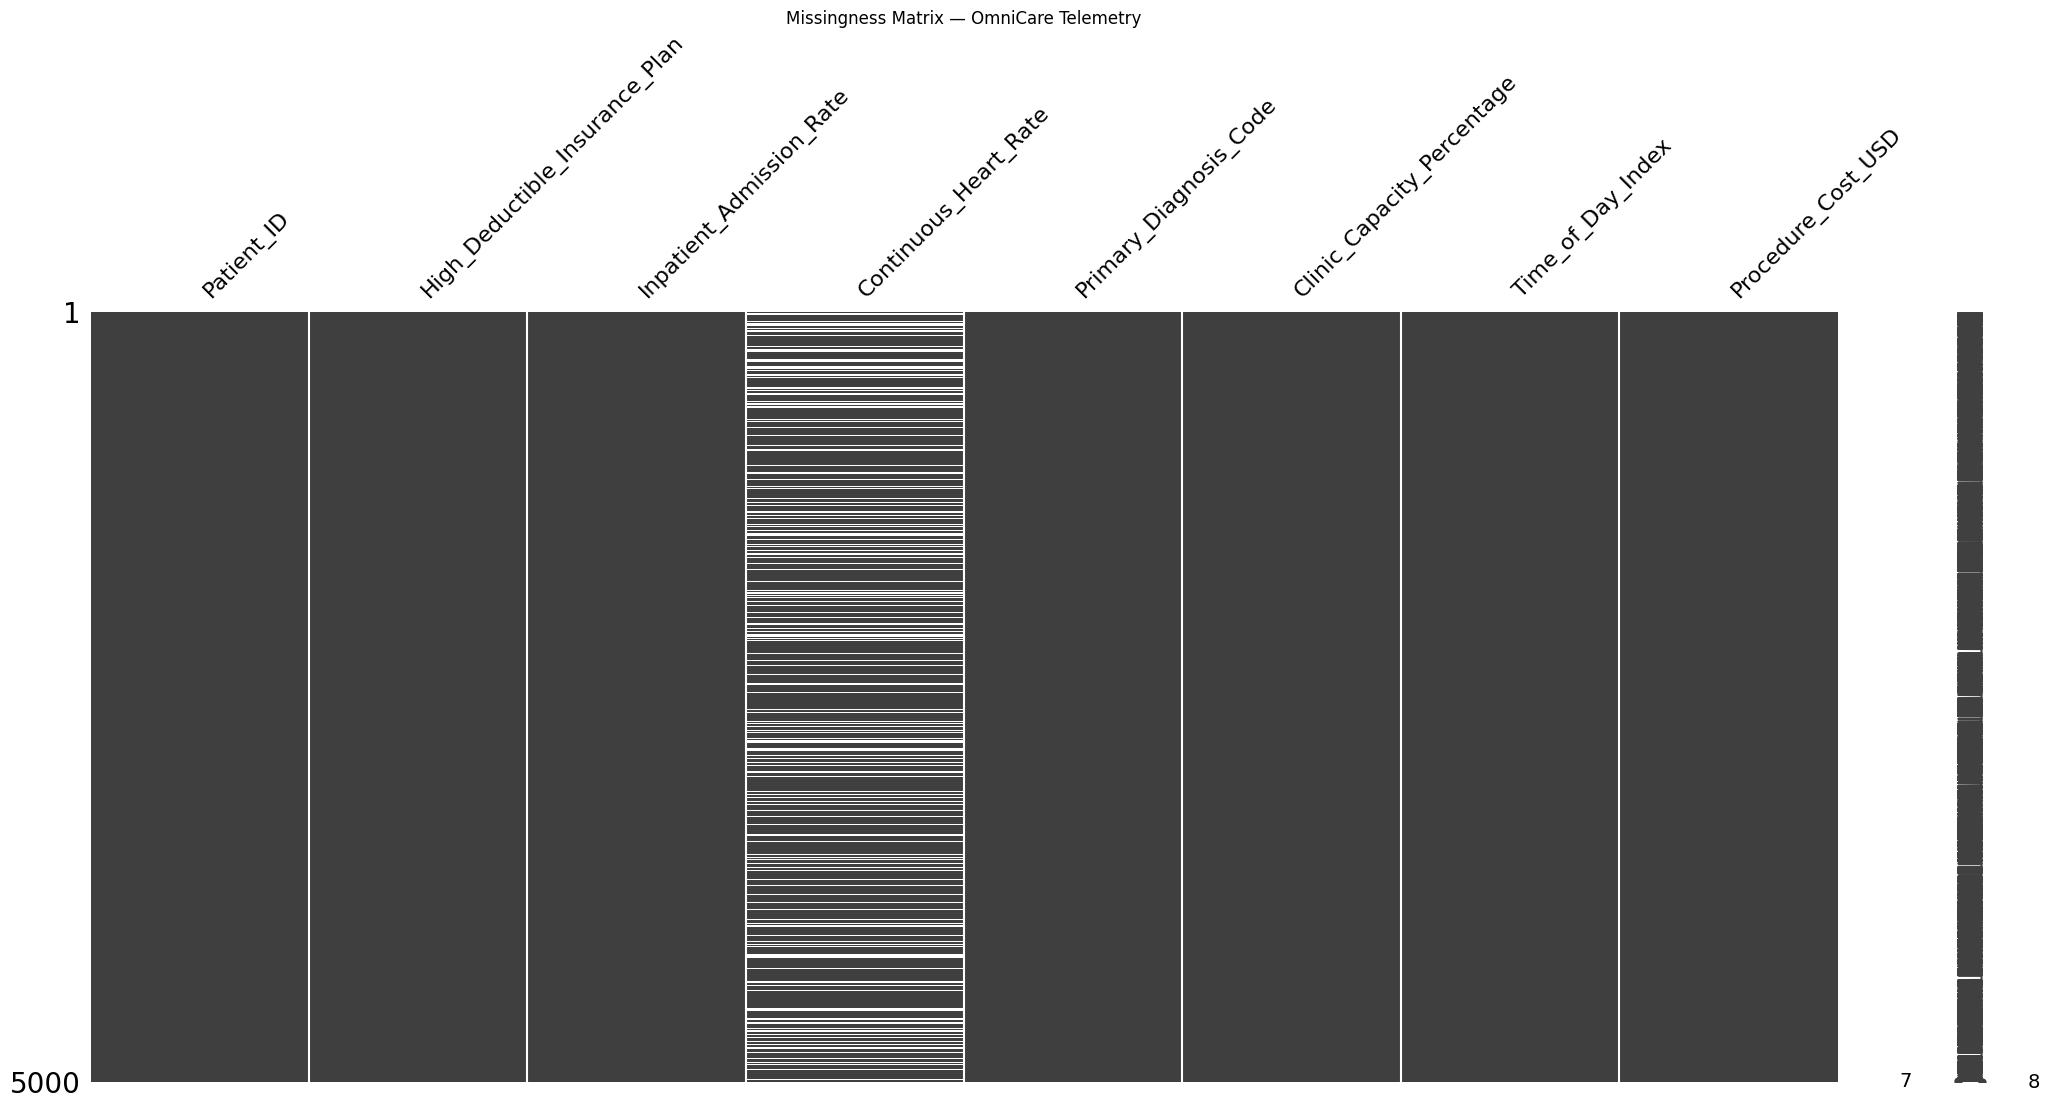

Missing in Continuous_Heart_Rate: 1214 / 5000


"\nMISSINGNESS CLASSIFICATION: MNAR (Missing Not At Random)\n\nRubin's taxonomy:\n  - MCAR: missingness is purely random, unrelated to any variable.\n  - MAR:  missingness depends on OTHER observed variables (e.g. age, diagnosis).\n  - MNAR: missingness depends on the UNOBSERVED VALUE ITSELF or on an\n          unobserved variable structurally linked to it.\n\nHere, low-income patients refuse to transmit because of data-plan costs —\na factor that is (a) unobserved in the dataset and (b) correlated with the\nvery patients whose heart-rate readings would likely differ systematically\nfrom wealthier patients. The probability of missingness P(R=0 | CHR, SES)\nis a function of SES, which is neither recorded nor ignorable.\n\nWhy mean imputation destroys integrity:\n  Mean imputation assumes MCAR — that the missing values are a random draw\n  from the same distribution as observed values. Under MNAR the missing\n  subgroup (low-SES) has a systematically different physiological profile.\n  F

In [ ]:
# Step 2.1: Missingness Matrix
df_telem = pd.read_csv("OmniCare_Telemetry_Data.csv")

msno.matrix(df_telem)
plt.title("Missingness Matrix — OmniCare Telemetry")
plt.tight_layout()
plt.show()

print(f"Missing in Continuous_Heart_Rate: {df_telem['Continuous_Heart_Rate'].isna().sum()} / {len(df_telem)}")

"""
MISSINGNESS CLASSIFICATION: MNAR (Missing Not At Random)

Rubin's taxonomy:
  - MCAR: missingness is purely random, unrelated to any variable.
  - MAR:  missingness depends on OTHER observed variables (e.g. age, diagnosis).
  - MNAR: missingness depends on the UNOBSERVED VALUE ITSELF or on an
          unobserved variable structurally linked to it.

Here, low-income patients refuse to transmit because of data-plan costs —
a factor that is (a) unobserved in the dataset and (b) correlated with the
very patients whose heart-rate readings would likely differ systematically
from wealthier patients. The probability of missingness P(R=0 | CHR, SES)
is a function of SES, which is neither recorded nor ignorable.

Why mean imputation destroys integrity:
  Mean imputation assumes MCAR — that the missing values are a random draw
  from the same distribution as observed values. Under MNAR the missing
  subgroup (low-SES) has a systematically different physiological profile.
  Filling with the global mean artificially pulls that subgroup toward the
  wealthy majority's baseline, biasing every downstream coefficient that
  touches Continuous_Heart_Rate and masking the socioeconomic signal entirely.
"""



In [ ]:
# Step 2.2: Dummy Variable Trap
n_codes = df_telem["Primary_Diagnosis_Code"].nunique()
print(f"Distinct ICD-10 codes: {n_codes}")

"""
DUMMY VARIABLE TRAP — MATRIX ALGEBRA

With K = {n_codes} diagnosis codes, pd.get_dummies() produces {n_codes} binary columns
d_1, d_2, ..., d_{n_codes}, each in {{0,1}}, satisfying the identity:

    d_1 + d_2 + ... + d_{n_codes} = 1   (every row belongs to exactly one code)

The design matrix X is constructed as:

    X = [1  | d_1  d_2  ...  d_{n_codes}]
         intercept col   dummy cols

The intercept column is EXACTLY equal to the sum of all dummy columns:

    1 = d_1 + d_2 + ... + d_{n_codes}

This means the columns of X are linearly dependent — the intercept lies in
the column space of the dummy matrix. Therefore:

    rank(X) = {n_codes}  <  {n_codes} + 1 = number of columns

A rank-deficient X^T X is singular (det = 0) and has no inverse.
The OLS estimator β̂ = (X^T X)^(-1) X^T y is mathematically undefined.

Fix: drop one reference category (drop_first=True), reducing to K-1 dummies.
"""



Distinct ICD-10 codes: 847


'\nDUMMY VARIABLE TRAP — MATRIX ALGEBRA\n\nWith K = {n_codes} diagnosis codes, pd.get_dummies() produces {n_codes} binary columns\nd_1, d_2, ..., d_{n_codes}, each in {{0,1}}, satisfying the identity:\n\n    d_1 + d_2 + ... + d_{n_codes} = 1   (every row belongs to exactly one code)\n\nThe design matrix X is constructed as:\n\n    X = [1  | d_1  d_2  ...  d_{n_codes}]\n         intercept col   dummy cols\n\nThe intercept column is EXACTLY equal to the sum of all dummy columns:\n\n    1 = d_1 + d_2 + ... + d_{n_codes}\n\nThis means the columns of X are linearly dependent — the intercept lies in\nthe column space of the dummy matrix. Therefore:\n\n    rank(X) = {n_codes}  <  {n_codes} + 1 = number of columns\n\nA rank-deficient X^T X is singular (det = 0) and has no inverse.\nThe OLS estimator β̂ = (X^T X)^(-1) X^T y is mathematically undefined.\n\nFix: drop one reference category (drop_first=True), reducing to K-1 dummies.\n'

In [ ]:
# Step 2.3: Target Encoding
encoder = ce.TargetEncoder(cols=["Primary_Diagnosis_Code"])

df_encoded = df_telem.copy()
df_encoded["Primary_Diagnosis_Code"] = encoder.fit_transform(
    df_telem[["Primary_Diagnosis_Code"]],
    df_telem["Procedure_Cost_USD"]
)

print("Target-Encoded Primary_Diagnosis_Code (first 5 rows)")
print(df_encoded[["Primary_Diagnosis_Code", "Procedure_Cost_USD"]].head())

Target-Encoded Primary_Diagnosis_Code (first 5 rows)
   Primary_Diagnosis_Code  Procedure_Cost_USD
0             1707.697108             1635.84
1             1792.303198             1355.77
2             1730.334968             1189.19
3             1725.060944             1250.93
4             1801.821085             1986.34


In [ ]:
# Step 3.1: OLS via Patsy Formula

df_vitals   = pd.read_csv("OmniCare_Clinical_Vitals.csv")
df_analytic = df_encoded.merge(df_vitals, on="Patient_ID", how="inner")
df_analytic = df_analytic.rename(columns={"Primary_Diagnosis_Code": "Target_Encoded_Diagnosis"})
df_analytic = df_analytic.dropna()

formula = ("Procedure_Cost_USD ~ Target_Encoded_Diagnosis + "
           "Clinic_Capacity_Percentage + Time_of_Day_Index + "
           "Height_cm + Weight_kg + Systolic_BP + Diastolic_BP")

model = smf.ols(formula=formula, data=df_analytic).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:     Procedure_Cost_USD   R-squared:                       0.254
Model:                            OLS   Adj. R-squared:                  0.253
Method:                 Least Squares   F-statistic:                     183.9
Date:                Tue, 24 Mar 2026   Prob (F-statistic):          3.87e-235
Time:                        03:43:55   Log-Likelihood:                -27366.
No. Observations:                3786   AIC:                         5.475e+04
Df Residuals:                    3778   BIC:                         5.480e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

In [ ]:
# Step 3.2: RMSE
from statsmodels.tools.eval_measures import rmse

predictions = model.fittedvalues
actuals     = df_analytic["Procedure_Cost_USD"]
model_rmse  = rmse(actuals, predictions)

print(f"\nRMSE: ${model_rmse:,.2f}")

"""
RMSE = $450 on a $1,200 procedure — analysis:

  Operational:  A ±$450 prediction error means bills can be off by ~37.5%
                before the procedure even occurs. Staff cannot give patients
                reliable cost estimates, destroying pre-authorization workflows.

  Financial:    Systematic over-prediction triggers underpayment disputes with
                insurers; under-prediction causes the hospital to absorb losses
                on high-complexity cases. At scale, variance of this magnitude
                compounds into multi-million dollar revenue leakage annually.

  Regulatory:   The No Surprises Act (2022) caps out-of-network billing variance
                and requires good-faith cost estimates. An algorithm with $450
                RMSE likely violates good-faith estimate thresholds, exposing
                the hospital to CMS audits, fines, and patient litigation.
                Dynamic pricing in healthcare also invites scrutiny under
                anti-discrimination statutes if prediction errors correlate
                with patient demographics.
"""




RMSE: $333.34


'\nRMSE = $450 on a $1,200 procedure — analysis:\n\n  Operational:  A ±$450 prediction error means bills can be off by ~37.5%\n                before the procedure even occurs. Staff cannot give patients\n                reliable cost estimates, destroying pre-authorization workflows.\n\n  Financial:    Systematic over-prediction triggers underpayment disputes with\n                insurers; under-prediction causes the hospital to absorb losses\n                on high-complexity cases. At scale, variance of this magnitude\n                compounds into multi-million dollar revenue leakage annually.\n\n  Regulatory:   The No Surprises Act (2022) caps out-of-network billing variance\n                and requires good-faith cost estimates. An algorithm with $450\n                RMSE likely violates good-faith estimate thresholds, exposing\n                the hospital to CMS audits, fines, and patient litigation.\n                Dynamic pricing in healthcare also invites scrutiny unde

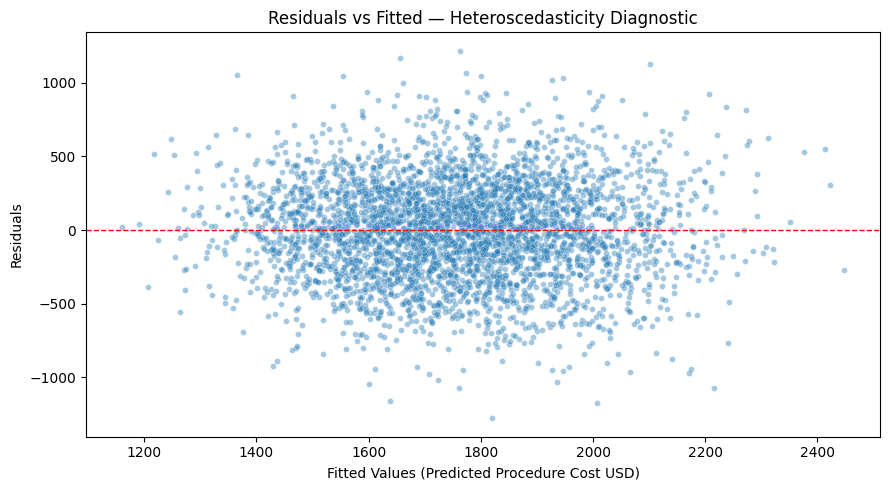

'\nHETEROSCEDASTICITY ANALYSIS:\n\nIf the residual scatter fans outward as fitted values increase (cone shape),\nthis is textbook heteroscedasticity — the error variance is not constant but\ngrows with the predicted cost level.\n\nImplication for surge-pricing tiers:\n  OLS assumes Var(ε) = σ² (constant). When variance scales with cost,\n  the model is systematically less reliable at high predicted values —\n  exactly the peak surge-pricing tier where pricing accuracy matters most.\n  Standard errors are understated, t-statistics are inflated, and confidence\n  intervals are too narrow, giving false precision to the most uncertain\n  predictions. A heteroscedasticity-robust estimator (HC3 standard errors)\n  or a log-transformed dependent variable would be required before deployment.\n'

In [ ]:
# Step 3.3: Residual Diagnostics
residuals_df = pd.DataFrame({
    "Fitted":    model.fittedvalues,
    "Residuals": model.resid
})

plt.figure(figsize=(9, 5))
sns.scatterplot(data=residuals_df, x="Fitted", y="Residuals", alpha=0.4, s=18)
plt.axhline(0, color="red", linewidth=1, linestyle="--")
plt.xlabel("Fitted Values (Predicted Procedure Cost USD)")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted — Heteroscedasticity Diagnostic")
plt.tight_layout()
plt.show()

"""
HETEROSCEDASTICITY ANALYSIS:

If the residual scatter fans outward as fitted values increase (cone shape),
this is textbook heteroscedasticity — the error variance is not constant but
grows with the predicted cost level.

Implication for surge-pricing tiers:
  OLS assumes Var(ε) = σ² (constant). When variance scales with cost,
  the model is systematically less reliable at high predicted values —
  exactly the peak surge-pricing tier where pricing accuracy matters most.
  Standard errors are understated, t-statistics are inflated, and confidence
  intervals are too narrow, giving false precision to the most uncertain
  predictions. A heteroscedasticity-robust estimator (HC3 standard errors)
  or a log-transformed dependent variable would be required before deployment.
"""

In [ ]:
"""
Persona: You are a senior econometrician specializing in healthcare cost modeling and OLS regression diagnostics.
Role: Your role is to write production-quality Python code for a tech economist auditing a hospital dynamic pricing algorithm built in statsmodels.
Instructions: Write a Python code cell that executes White's Lagrange Multiplier Test for heteroscedasticity on a fitted statsmodels OLS result object named model, using statsmodels.stats.diagnostic.het_white. Extract and print the LM statistic and its p-value. Then print a concluding sentence stating whether the null hypothesis of homoscedasticity is rejected at the 5% significance level.
Meaning: The test result will determine whether the OLS standard errors in a live hospital procedure-cost prediction engine are trustworthy, with direct regulatory and financial consequences under the No Surprises Act.
Evaluation: The code must run without errors in a Colab cell where model is already defined, use only statsmodels and numpy, and produce a clearly labeled printed output.
"""



# Step 4.1: White's LM Test for Heteroscedasticity
from statsmodels.stats.diagnostic import het_white

lm_stat, lm_pvalue, f_stat, f_pvalue = het_white(model.resid, model.model.exog)

print(f"White's LM Statistic : {lm_stat:.4f}")
print(f"LM Test p-value      : {lm_pvalue:.4f}")
print()

if lm_pvalue < 0.05:
    print(f"Conclusion: p = {lm_pvalue:.4f} < 0.05. The null hypothesis of homoscedasticity "
          f"is rejected. Significant heteroscedasticity is present in the model residuals.")
else:
    print(f"Conclusion: p = {lm_pvalue:.4f} >= 0.05. We fail to reject the null hypothesis. "
          f"No significant evidence of heteroscedasticity detected.")

White's LM Statistic : 159.2136
LM Test p-value      : 0.0000

Conclusion: p = 0.0000 < 0.05. The null hypothesis of homoscedasticity is rejected. Significant heteroscedasticity is present in the model residuals.
